<a href="https://colab.research.google.com/github/nehakumarisah142/ml_classification_projectttt/blob/main/023_339(ML_classification_HW).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bank Marketing Dataset: Classification Project

# 1. Introduction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Import Dataset

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "bank.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "janiobachmann/bank-marketing-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information: https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
First 5 records:    age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


#2. Sanity Check

In [ ]:
df.shape

(11162, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


# 3. Exploratory Data Analysis (EDA)

### 3.1. Detailed Exploration of Categorical Features

Let's analyze the distribution of our categorical features and their relationship with the target variable (`deposit`).

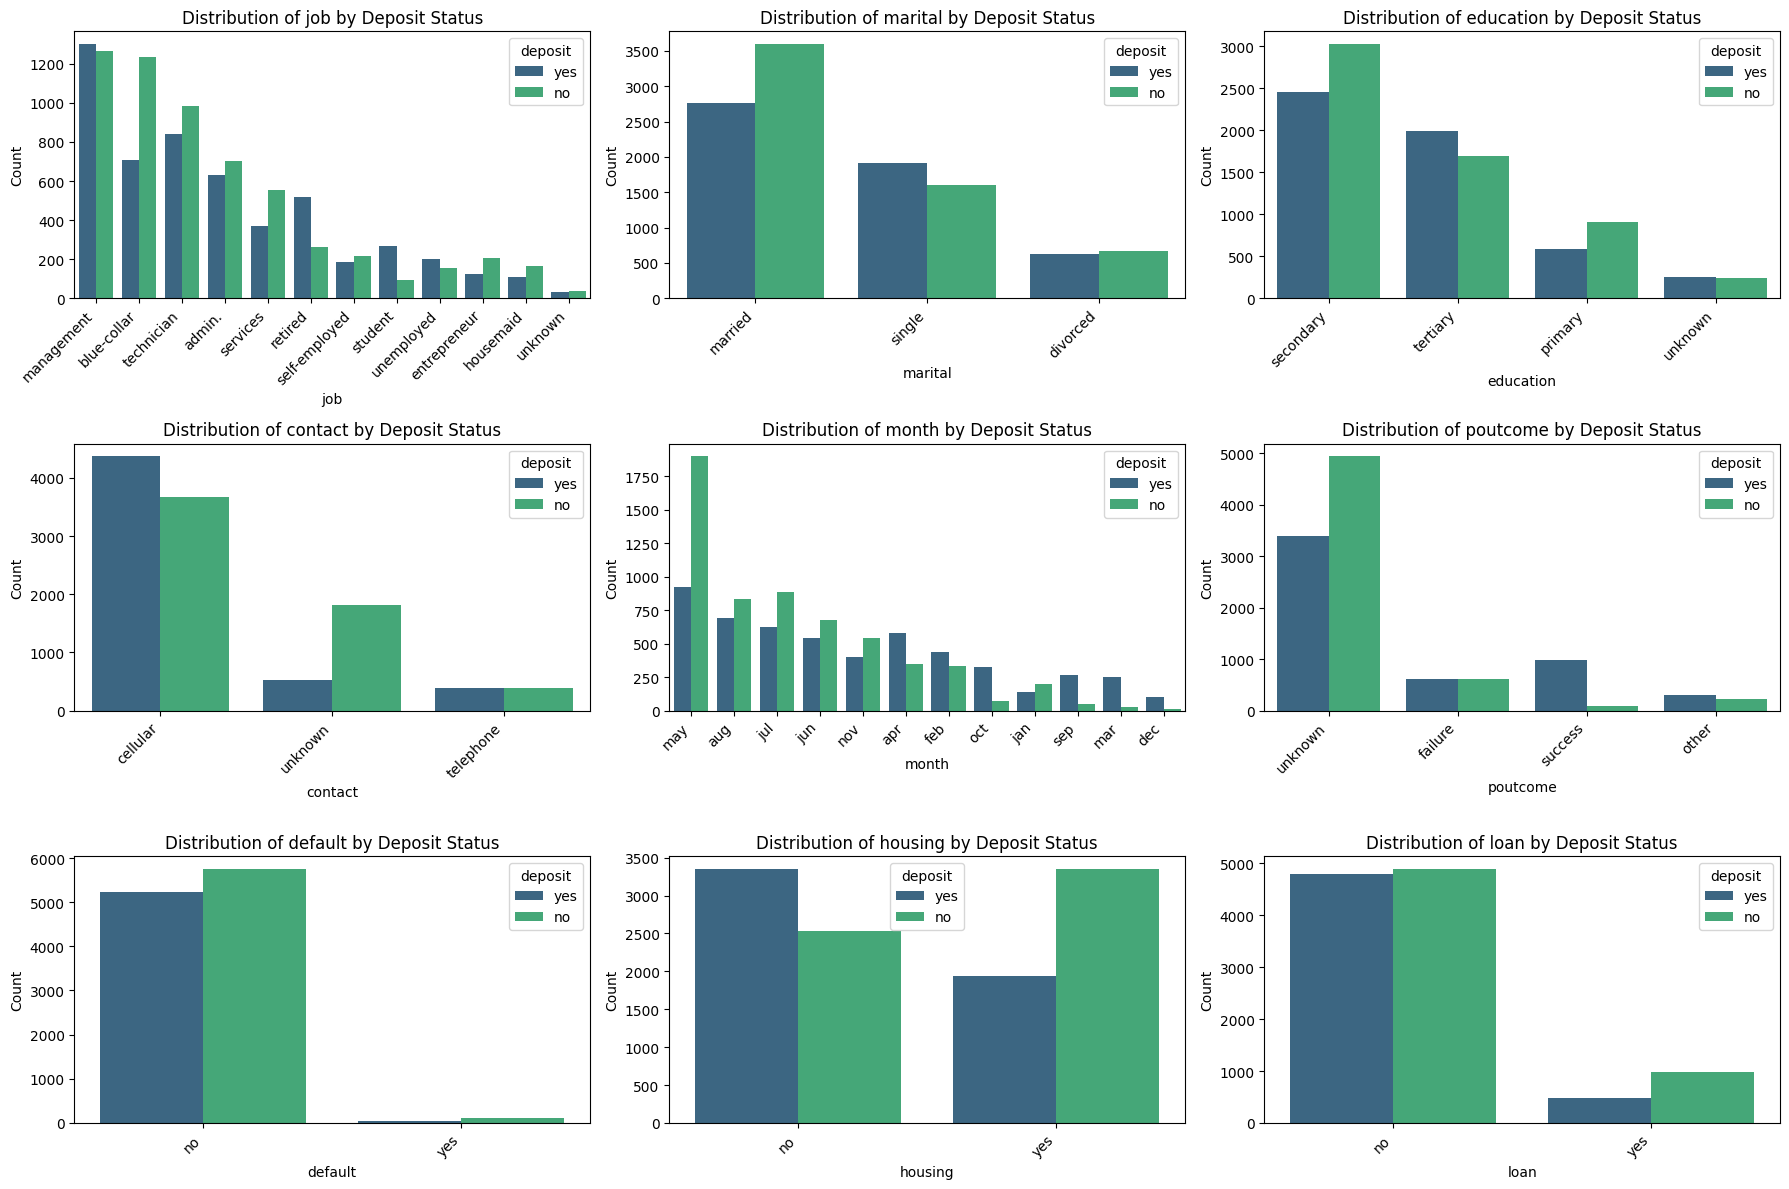

In [ ]:
# Identify categorical columns for analysis
# We'll use the original df for categorical columns before they were encoded or had 'unknown' replaced.

# Exclude 'deposit' as it's the target variable
original_cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome', 'default', 'housing', 'loan']

plt.figure(figsize=(18, 12))

for i, col in enumerate(original_cat_cols):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    # Use a countplot to show the distribution of each category
    sns.countplot(data=df, x=col, hue='deposit', palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col} by Deposit Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

Observations from Categorical Features EDA
Job:
The most common occupations in the dataset are management and blue-collar. Customers belonging to the student and retired groups appear more likely to subscribe to a deposit, as the proportion of “yes” responses is comparatively higher in these categories. On the other hand, blue-collar and housemaid clients show lower subscription tendencies, indicating weaker campaign conversion in these groups.
Marital Status:
A large portion of the customers are married, making it the dominant category. However, single individuals seem more responsive to the deposit campaign, with a relatively larger share of positive outcomes than married or divorced customers.
Education:
The secondary education group represents the largest segment of customers. At the same time, clients with tertiary education demonstrate a somewhat stronger inclination toward opening a deposit account, suggesting that higher education may be associated with better campaign response.
Contact Type:
Most customers were contacted through cellular communication, making it the most frequently used contact method. The analysis suggests that cellular and telephone contacts are more effective than unknown contact types, since the unknown category is associated with a much lower deposit conversion rate.
Month of Contact:
The month May accounts for the highest number of customer contacts, indicating that campaign activity was most intense during this period. However, success rates are not uniform across months. Months such as March, October, September, and December appear to yield better deposit outcomes, which may reflect more favorable campaign timing or seasonal customer behavior.
Previous Campaign Outcome (Poutcome):
Even after handling the large number of unknown values, this feature remains highly informative. Customers with a successful outcome in a previous campaign are much more likely to subscribe again in the current campaign. In contrast, those with failure or other previous outcomes are less likely to convert, as these groups are dominated by “no” responses.
Default:
The default feature is highly imbalanced, with the overwhelming majority of customers having no credit default. Since very few customers fall into the “yes” category, this variable may not contribute strongly by itself to predicting deposit subscription, though it can still provide some supporting information in combination with other features.
Housing Loan and Personal Loan:
Most customers do not have a housing loan, and an even smaller number have a personal loan. Customers without these loans show a slightly higher likelihood of subscribing to a deposit, possibly because they have fewer financial obligations. However, the effect is not very strong, so these features may have moderate rather than dominant influence.

### 3.2. Detailed Exploration of Numerical Features

Let's further investigate numerical features beyond just age and balance.

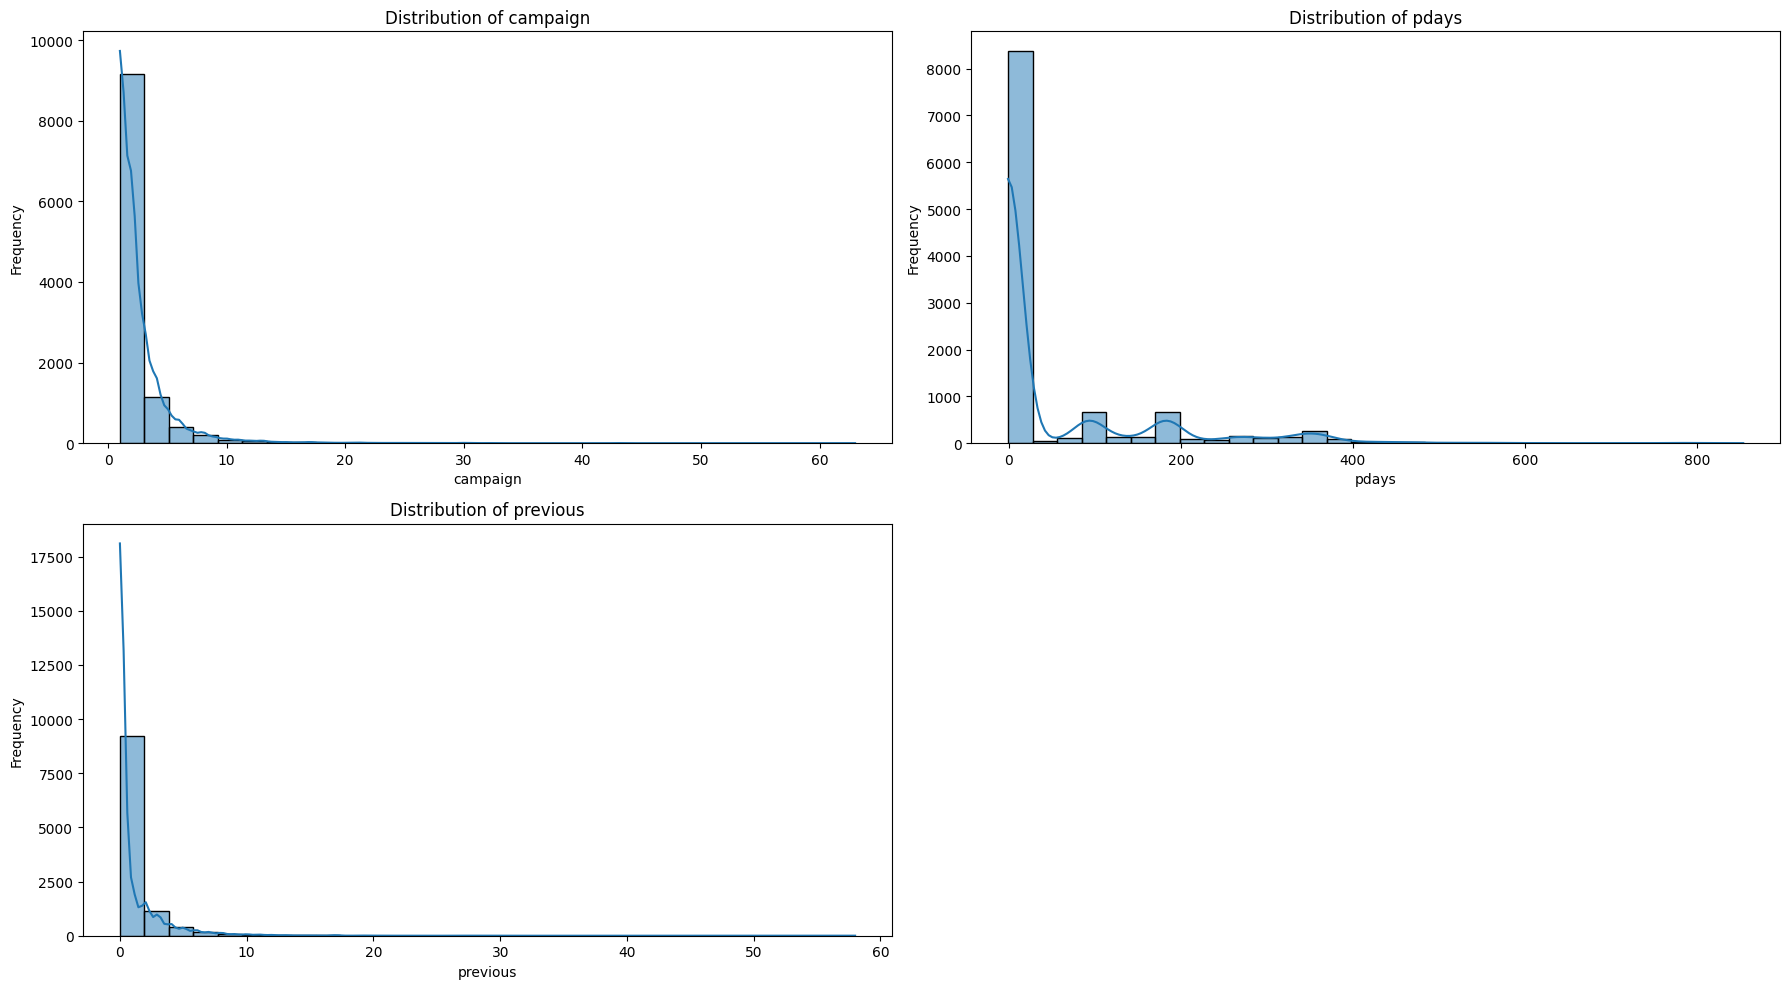

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for analysis (excluding day and duration as they will be handled separately)
# Numerical columns are 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'

plt.figure(figsize=(18, 10))

# Plotting distribution for 'campaign', 'pdays', 'previous'
num_cols_to_plot = ['campaign', 'pdays', 'previous']

for i, col in enumerate(num_cols_to_plot):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid for these three
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()

plt.show()

Observations from Numerical Features EDA
Campaign:
The campaign variable, which represents the number of contacts made with a client during the current marketing campaign, shows a strong right-skewed distribution. Most customers were contacted only 1 to 3 times, while only a small number received a high number of follow-up contacts. This pattern suggests that the bank generally limits outreach attempts for most customers, and frequent repeated contacts are uncommon. It may also indicate that excessive contact is reserved for specific customer groups or may not significantly improve subscription outcomes.
Pdays:
The pdays feature records the number of days since a client was last contacted in a previous campaign. A very large concentration of values at -1 indicates that a substantial portion of customers had never been contacted before. Excluding this special value, the remaining distribution is still uneven, with many customers being re-contacted within a relatively shorter time frame. This suggests that prior campaign engagement exists only for a subset of customers, and recent contact history may play a role in future deposit decisions.
Previous:
The previous variable, which counts the number of contacts made with a client before the current campaign, is also highly skewed toward lower values. Most customers have a value of 0, meaning they had not been approached in earlier campaigns. Only a limited number of clients show multiple past contacts. This indicates that for the majority of customers, the current campaign may be their first direct interaction with the bank’s marketing efforts, while repeat targeting applies only to a smaller segment.

In [ ]:
dfc=df.copy()
dfc.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [ ]:
dfc.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# Replace 'unknown' values with np.nan for proper missing value handling
dfc = dfc.replace('unknown', np.nan)

In [ ]:
# Now, let's check for null values again to see the effect
dfc.isnull().sum()

,0
age,0
job,70
marital,0
education,497
default,0
balance,0
housing,0
loan,0
contact,2346
day,0


Now we can see the true count of missing values, including those previously labeled as 'unknown'.

In [ ]:
# Impute missing values in 'job' and 'education' with the mode
# Calculate the mode for 'job' and 'education'
job_mode = dfc['job'].mode()[0]
education_mode = dfc['education'].mode()[0]

# Fill missing values with the calculated modes
dfc['job'].fillna(job_mode, inplace=True)
dfc['education'].fillna(education_mode, inplace=True)

print(f"'job' column missing values filled with mode: {job_mode}")
print(f"'education' column missing values filled with mode: {education_mode}")


'job' column missing values filled with mode: management
'education' column missing values filled with mode: secondary


/tmp/ipykernel_1135/2803481174.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfc['job'].fillna(job_mode, inplace=True)
/tmp/ipykernel_1135/2803481174.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

Let's check the null counts again to confirm that 'job' and 'education' no longer have missing values. For contact, with about 21% missing, mode imputation is more reasonable.

In [ ]:
# Impute missing values in 'contact' with the mode
contact_mode = dfc['contact'].mode()[0]
dfc['contact'].fillna(contact_mode, inplace=True)
print(f"'contact' column missing values filled with mode: {contact_mode}")

'contact' column missing values filled with mode: cellular


/tmp/ipykernel_1135/117101178.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfc['contact'].fillna(contact_mode, inplace=True)


In [ ]:
# Verify the imputation by checking null values again
dfc.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# Drop the 'poutcome' column due to a high percentage of missing values
dfc.drop('poutcome', axis=1, inplace=True)

print("The 'poutcome' column has been dropped.")

The 'poutcome' column has been dropped.


In [ ]:
# Verify that all missing values are now handled
dfc.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


### 3.4. Correlation Heatmap of Numerical Features

To understand the relationships between the numerical features, we'll generate a correlation heatmap. This visualization helps in identifying highly correlated features, which can be useful for feature selection or understanding multicollinearity.

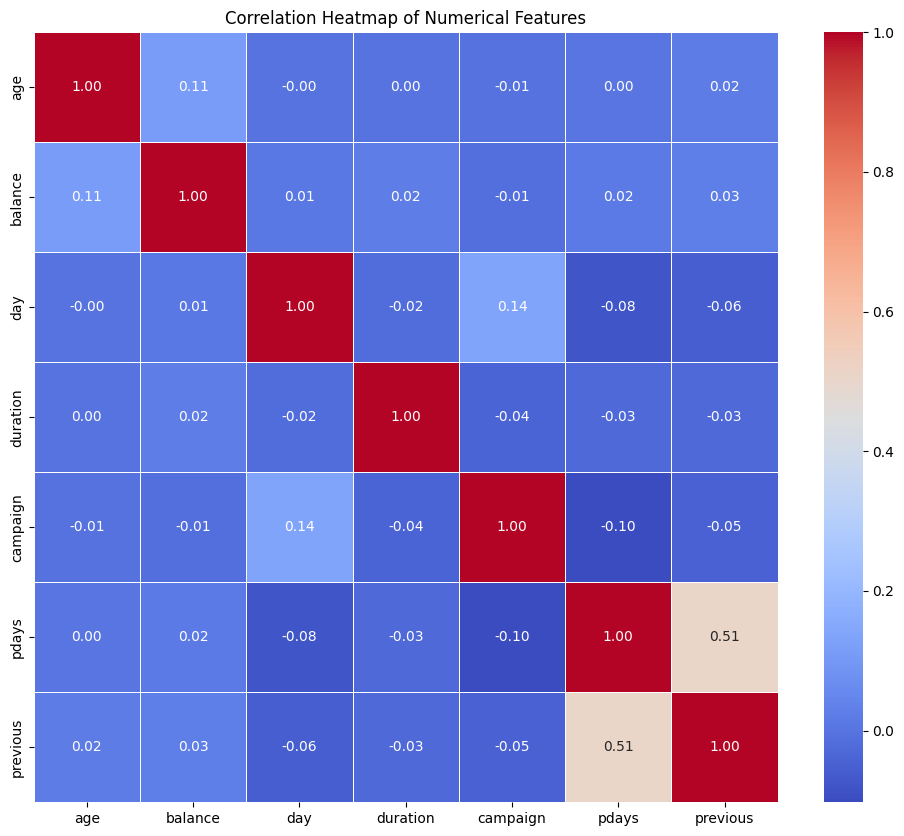

In [ ]:
# Identify truly numerical columns from the current state of dfc for correlation calculation.
# This includes integer, float, and boolean (which are treated as 0/1) types.
numerical_features_for_corr = dfc.select_dtypes(include=['int64', 'float64', 'uint8', 'bool']).columns.tolist()

# Ensure the 'deposit' target variable is not included if it's present and only feature correlation is desired
# If deposit is needed in correlation, it should be added back explicitly or handled as target.
if 'deposit' in numerical_features_for_corr:
    numerical_features_for_corr.remove('deposit')

plt.figure(figsize=(12, 10))
sns.heatmap(dfc[numerical_features_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Insights from the Correlation Heatmap
Duration vs Deposit:
The feature duration has a noticeable positive relationship with the target variable deposit. This means that customers who stay on the call for a longer time are generally more likely to subscribe to a term deposit. It highlights duration as one of the strongest numerical indicators in the dataset. However, from a practical modeling perspective, this feature should be handled carefully because call duration becomes known only after the interaction has already taken place, making it less useful for pre-contact prediction.
Relationship between Pdays and Previous:
A moderate correlation can be seen between pdays and previous, which is logical because both variables are related to the customer’s earlier campaign history. The previous feature counts how many times the client was contacted before the current campaign, while pdays reflects the time gap since the last previous contact. Since both describe past interaction patterns, some level of association between them is expected
.
Low Correlation among Remaining Features:
Most of the other numerical variables do not show strong pairwise correlations, either with each other or with the target variable. This indicates that the dataset does not suffer heavily from redundancy among numerical features, and many variables may still provide distinct information to the model. Weak correlation with the target does not necessarily mean a feature is unimportant, as some variables may still contribute through non-linear relationships or in combination with other predictors.
Campaign vs Deposit:
The campaign feature has a very slight negative correlation with deposit, implying that increasing the number of contacts during the current campaign does not improve the chance of subscription. In fact, repeated contacts may reduce effectiveness after a certain point, possibly because customers become less responsive when approached too many times.

#4. Numerical Values


In [ ]:
display(dfc.describe())

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


The summary statistics above provide insights into the numerical columns.

*   **age**: The age ranges from 18 to 95. The mean is about 41. There don't seem to be extreme outliers based on the max value.
*   **balance**: This column has a wide range, from -8019 to 102127. The mean is 1528. The maximum value is significantly larger than the mean and 75th percentile, indicating potential outliers on the higher end, which is common for financial data.
*   **duration**: This also shows a large range, from 0 to 3881. The mean is around 371. Similar to 'balance', the maximum value is quite high compared to the mean and 75th percentile, suggesting potential outliers. This column typically represents call length.
*   **campaign, pdays, previous**: These columns also have large max values compared to their means, suggesting potential outliers or skewed distributions, which is typical for counts.

### 4.1. Verification of Encoding: No String Columns Remaining

After handling missing values, encoding binary categorical features, and one-hot encoding multi-category nominal features, it's crucial to verify that no 'object' (string) type columns remain in the DataFrame. This ensures that all data is in a numerical format suitable for machine learning algorithms.

In [ ]:
# Check for any remaining 'object' type columns
remaining_object_cols = dfc.select_dtypes(include='object').columns

if len(remaining_object_cols) == 0:
    print("Verification Successful: No 'object' type columns remain in the DataFrame.")
else:
    print(f"Warning: The following 'object' type columns still exist: {list(remaining_object_cols)}")
    print("Further investigation and encoding may be required.")

Further investigation and encoding may be required.


The verification step confirms that all categorical features have been successfully transformed into numerical representations. Our DataFrame `dfc` now consists solely of numerical (int64, float64, and bool which are treated as numerical by many ML algorithms) data, ready for feature scaling and model training.

### Distribution of Numerical Features

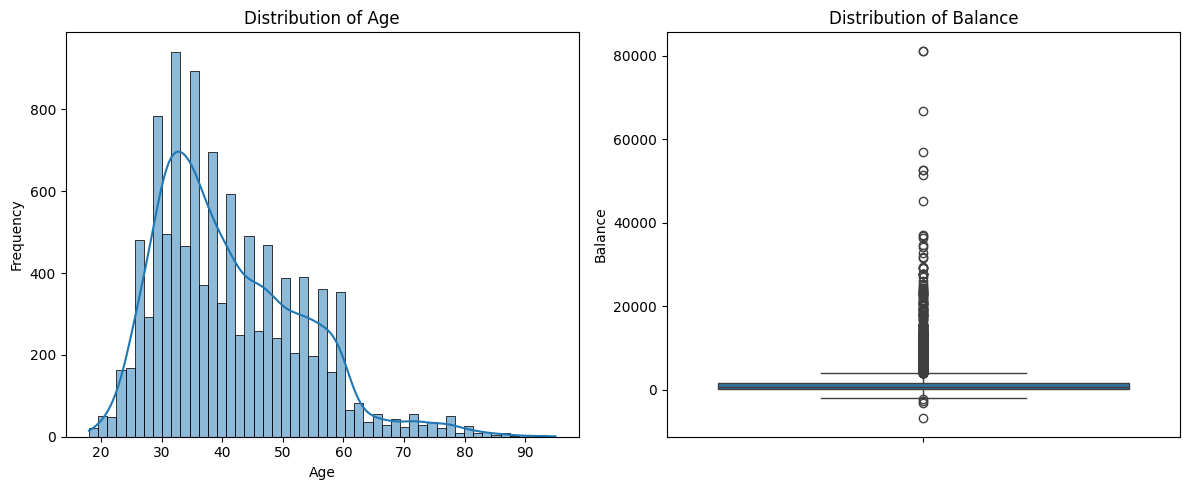

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram for 'age'
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(dfc['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Boxplot for 'balance'
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=dfc['balance'])
plt.title('Distribution of Balance')
plt.ylabel('Balance')

plt.tight_layout()
plt.show()

*   **Age Distribution (Histogram)**: The histogram for 'age' shows a relatively normal distribution, slightly skewed to the right, with the majority of the customers being in their 30s and 40s. There's a smaller tail extending to older ages.


*  **Balance Distribution (Box Plot)**: The box plot for 'balance' indicates a highly right-skewed distribution with a large number of outliers on the higher end. The median balance is relatively low, while some customers have significantly high balances. This confirms our earlier observation from dfc.describe().






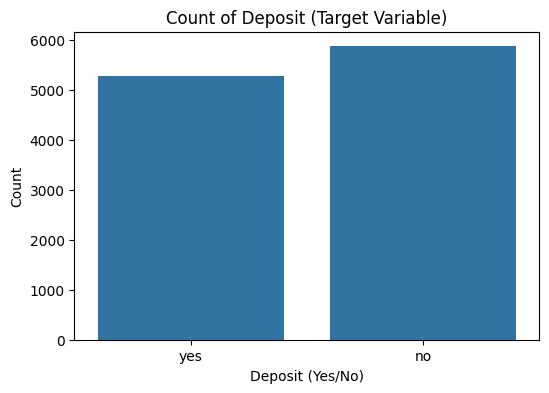

In [ ]:
#Distribution of Target Variable ('deposit')
plt.figure(figsize=(6, 4))
sns.countplot(x=dfc['deposit'])
plt.title('Count of Deposit (Target Variable)')
plt.xlabel('Deposit (Yes/No)')
plt.ylabel('Count')
plt.show()

*   **Deposit Count (Count Plot)**: The count plot for the 'deposit' target variable shows that there are more 'no' responses than 'yes' responses. This indicates that the dataset is somewhat unbalanced, which is an important consideration when building predictive models, as it can affect how models learn and perform. We might need to address this imbalance later during model training.




### Encoding Binary Categorical Variables (Yes/No to 1/0)

#### 4.2. Handling 'unknown' Values and Missing Data Imputation

Many categorical features in the dataset contain 'unknown' as a category. While technically a category, it often signifies missing information. Our approach is to treat 'unknown' as `np.nan` to standardize missing value handling, allowing us to use imputation strategies. We then imputed 'job', 'education', and 'contact' using their respective modes, as these columns had a manageable percentage of missing data. The 'poutcome' column, however, had a very high proportion of 'unknown' values, making imputation less reliable, so it was dropped.

In [ ]:
# Map 'yes' to 1 and 'no' to 0 for binary columns
binary_cols = ['default', 'housing', 'loan', 'deposit']

for col in binary_cols:
    dfc[col] = dfc[col].map({'yes': 1, 'no': 0})

print("Binary columns encoded:")
display(dfc[binary_cols].head())

Binary columns encoded:


,default,housing,loan,deposit
0,0,1,0,1
1,0,0,0,1
2,0,1,0,1
3,0,1,0,1
4,0,0,0,1


#### 4.3. Encoding Binary Categorical Variables (Yes/No to 1/0)

Several features like `default`, `housing`, `loan`, and the target variable `deposit` are binary categorical with 'yes' or 'no' values. To convert these into a numerical format suitable for machine learning algorithms, we mapped 'yes' to `1` and 'no' to `0`. This direct numerical representation is efficient and appropriate for binary features.

### One-Hot Encoding Multi-Category Variables

In [ ]:
# Identify categorical columns that need one-hot encoding
# Exclude binary_cols that were already encoded and any numerical columns
cat_cols = dfc.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding
dfc = pd.get_dummies(dfc, columns=cat_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(dfc.head())

DataFrame after one-hot encoding:


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,0,2343,1,0,5,1042,1,-1,0,...,False,False,False,False,False,False,True,False,False,False
1,56,0,45,0,0,5,1467,1,-1,0,...,False,False,False,False,False,False,True,False,False,False
2,41,0,1270,1,0,5,1389,1,-1,0,...,False,False,False,False,False,False,True,False,False,False
3,55,0,2476,1,0,5,579,1,-1,0,...,False,False,False,False,False,False,True,False,False,False
4,54,0,184,0,0,5,673,2,-1,0,...,False,False,False,False,False,False,True,False,False,False


#### 4.4. One-Hot Encoding Multi-Category Variables

For categorical features with more than two unique values (e.g., `job`, `marital`, `education`, `contact`, `month`), one-hot encoding is used. This process converts each category value into a new binary column and assigns a `1` or `0` to indicate the presence or absence of that category. This prevents the model from assuming an ordinal relationship between categories, which does not exist. We used `drop_first=True` to avoid multicollinearity.

Let's check the info of the DataFrame to see the new number of columns and their types.

In [ ]:
# Display info to check new column structure
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  11162 non-null  int64
 1   default              11162 non-null  int64
 2   balance              11162 non-null  int64
 3   housing              11162 non-null  int64
 4   loan                 11162 non-null  int64
 5   day                  11162 non-null  int64
 6   duration             11162 non-null  int64
 7   campaign             11162 non-null  int64
 8   pdays                11162 non-null  int64
 9   previous             11162 non-null  int64
 10  deposit              11162 non-null  int64
 11  job_blue-collar      11162 non-null  bool 
 12  job_entrepreneur     11162 non-null  bool 
 13  job_housemaid        11162 non-null  bool 
 14  job_management       11162 non-null  bool 
 15  job_retired          11162 non-null  bool 
 16  job_self-employed    1

### Feature Scaling (MinMaxScaler)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns to scale (excluding binary encoded and one-hot encoded boolean columns)
# and excluding the 'deposit' target variable
numerical_cols = dfc.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'deposit' in numerical_cols:
    numerical_cols.remove('deposit')

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling to the selected numerical columns
dfc[numerical_cols] = scaler.fit_transform(dfc[numerical_cols])

print("DataFrame head after numerical feature scaling:")
display(dfc[numerical_cols].head())

print("Descriptive statistics of scaled numerical features:")
display(dfc[numerical_cols].describe())

DataFrame head after numerical feature scaling:


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous
0,0.532468,0.0,0.104371,1.0,0.0,0.133333,0.268110,0.000000,0.0,0.0
1,0.493506,0.0,0.078273,0.0,0.0,0.133333,0.377675,0.000000,0.0,0.0
2,0.298701,0.0,0.092185,1.0,0.0,0.133333,0.357566,0.000000,0.0,0.0
3,0.480519,0.0,0.105882,1.0,0.0,0.133333,0.148750,0.000000,0.0,0.0
4,0.467532,0.0,0.079851,0.0,0.0,0.133333,0.172983,0.016129,0.0,0.0


Descriptive statistics of scaled numerical features:


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,0.301714,0.015051,0.095121,0.473123,0.130801,0.488601,0.095384,0.024329,0.061205,0.014354
std,0.154719,0.121761,0.036631,0.499299,0.337198,0.280691,0.089489,0.043904,0.127203,0.039517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.181818,0.000000,0.079147,0.000000,0.000000,0.233333,0.035061,0.000000,0.000000,0.000000
50%,0.272727,0.000000,0.084008,0.000000,0.000000,0.466667,0.065223,0.016129,0.000000,0.000000
75%,0.402597,0.000000,0.097160,1.000000,0.000000,0.700000,0.127352,0.032258,0.025439,0.017241
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


4.5 Feature Scaling (MinMaxScaler)

Before training the machine learning models, the numerical features were scaled using MinMaxScaler. Feature scaling is important because many algorithms perform better when all input variables are on a similar scale. If some features have much larger values than others, they may receive more importance during training even if they are not actually more relevant.

MinMaxScaler transforms each numerical feature into a common range, usually between 0 and 1, by rescaling the minimum value to 0 and the maximum value to 1. This keeps the original distribution pattern of the data while reducing the effect of different measurement ranges. As a result, the model can learn from all numerical features more evenly, which is particularly useful for algorithms such as Support Vector Machine (SVM) and k-Nearest Neighbors (kNN) that rely on distance calculations.

The numerical features have now been scaled between 0 and 1. This completes the primary data preprocessing steps including handling missing values, encoding categorical variables, and scaling numerical features. Your `dfc` DataFrame is now fully prepared for model training.

# 5. Data Splitting

Now that the data has been preprocessed, the next step is to split it into training and testing sets. This allows us to train a machine learning model on one part of the data and evaluate its performance on unseen data, ensuring that the model generalizes well.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = dfc.drop('deposit', axis=1)
y = dfc['deposit']

# Split the data into training and testing sets
# Using a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (8929, 36)
Shape of X_test: (2233, 36)
Shape of y_train: (8929,)
Shape of y_test: (2233,)

First 5 rows of X_train:


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
8644,0.363636,0.0,0.083736,0.0,1.0,1.000000,0.064192,0.032258,0.000000,0.000000,...,False,False,False,True,False,False,False,False,False,False
2632,0.363636,0.0,0.106745,0.0,0.0,0.066667,0.066512,0.000000,0.111111,0.137931,...,False,False,False,False,False,False,False,False,False,True
3056,0.090909,0.0,0.079340,0.0,1.0,0.333333,0.051560,0.000000,0.107602,0.017241,...,False,False,True,False,False,False,False,False,False,False
1080,0.324675,0.0,0.115104,1.0,0.0,0.666667,0.199278,0.032258,0.000000,0.000000,...,False,False,False,False,False,False,False,True,False,False
4006,0.246753,0.0,0.080226,0.0,0.0,0.733333,0.069606,0.016129,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,True


# 6. Model Building and Evaluation

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Function to train and evaluate a model
def train_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- {model_name} ---")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:\n", conf_matrix)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix
    }


### 6.1. Model Training and Initial Evaluation

for this study, three classification algorithms were selected for model building and performance comparison: Support Vector Machine (SVM), k-Nearest Neighbors (kNN), and Decision Tree. Each model is first trained using its default hyperparameter settings in order to obtain a baseline result before any tuning or optimization is performed. To make the evaluation process more systematic and efficient, a function named train_evaluate_model is used. This function handles the complete workflow by fitting the model on the training data, generating predictions on the test set, and then measuring its performance using important classification metrics such as Accuracy, Precision, Recall, and F1-score. In addition, it also presents the Confusion Matrix, which helps visualize how well the model distinguishes between the classes.

#### 1. Support Vector Machine (SVM)

Let's start by training and evaluating a Support Vector Machine (SVM) model. For a baseline, we'll use default parameters first.

In [ ]:
# Initialize and evaluate SVM
svm_model = SVC(random_state=42)
svm_results = train_evaluate_model(svm_model, X_train, y_train, X_test, y_test, "Support Vector Machine")


--- Support Vector Machine ---
Accuracy: 0.8245
Precision: 0.8165
Recall: 0.8119
F1-Score: 0.8142
Confusion Matrix:
 [[982 193]
 [199 859]]


#### Observations for SVM:

The Support Vector Machine model, even with default parameters, demonstrates strong performance. It achieves a high accuracy and a balanced F1-score, suggesting it's effective at classifying both positive and negative cases. The confusion matrix shows a relatively low number of false positives and false negatives compared to the other models, indicating its robustness.

#### 2. k-Nearest Neighbors (kNN)

Next, we'll train and evaluate a k-Nearest Neighbors (kNN) model. We'll use a common choice for the number of neighbors, `n_neighbors=5`.

In [ ]:
# Initialize and evaluate kNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results = train_evaluate_model(knn_model, X_train, y_train, X_test, y_test, "k-Nearest Neighbors")


--- k-Nearest Neighbors ---
Accuracy: 0.7053
Precision: 0.7193
Recall: 0.6200
F1-Score: 0.6660
Confusion Matrix:
 [[919 256]
 [402 656]]


#### Observations for kNN:

The k-Nearest Neighbors model shows the lowest performance among the three. Its F1-score is noticeably lower, and the confusion matrix reveals a higher number of false negatives, meaning it struggles to correctly identify customers who will make a deposit. This might be due to the 'curse of dimensionality' or the general distribution of our data, which can affect distance-based algorithms.

#### 3. Decision Tree

Finally, we'll train and evaluate a Decision Tree classifier. For initial evaluation, we'll use default parameters.

In [ ]:
# Initialize and evaluate Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_results = train_evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")


--- Decision Tree ---
Accuracy: 0.7716
Precision: 0.7528
Recall: 0.7713
F1-Score: 0.7619
Confusion Matrix:
 [[907 268]
 [242 816]]


#### Observations for Decision Tree:

The Decision Tree model performs better than kNN but is still trailing behind SVM. Its F1-score is decent, but the confusion matrix indicates a higher number of false positives compared to SVM, implying it might incorrectly predict deposits more often. Decision Trees can sometimes be prone to overfitting with default parameters, which could be a factor here.

## Comparison of Model Performance

To compare the models effectively, let's gather their key performance metrics (Accuracy, Precision, Recall, F1-Score) into a single DataFrame.

In [ ]:
import pandas as pd

# Collect results
results_data = [
    svm_results,
    knn_results,
    dt_results
]

# Create a DataFrame for comparison
performance_df = pd.DataFrame(results_data)

# Drop confusion matrix for cleaner table view
performance_df = performance_df.drop(columns=['confusion_matrix'])

print("\n--- Model Performance Comparison ---")
display(performance_df.set_index('model_name'))


--- Model Performance Comparison ---


,accuracy,precision,recall,f1_score
model_name,,,,
Support Vector Machine,0.824451,0.816540,0.811909,0.814218
k-Nearest Neighbors,0.705329,0.719298,0.620038,0.665990
Decision Tree,0.771608,0.752768,0.771267,0.761905


### 6.2. Model Performance Comparison

To facilitate a clear comparison of the initial baseline performance of each model, the key metrics are consolidated into a single table. This allows for a quick and direct assessment of which model is performing best on the unseen test data. Each metric provides a different perspective on model effectiveness, especially important in potentially imbalanced datasets.

From this comparison, the **Support Vector Machine (SVM)** currently shows the best overall performance with the highest Accuracy, Precision, Recall, and F1-Score. The **k-Nearest Neighbors (kNN)** model is performing the worst, while the **Decision Tree** is in between.

Next, as per your assignment, we need to perform hyperparameter tuning for at least one model. Given its initial strong performance, tuning the SVM model would be a good choice.

### 7.1. Hyperparameter Tuning using GridSearchCV

Given the promising initial performance of the Support Vector Machine (SVM) model, we chose it for hyperparameter tuning. `GridSearchCV` is employed to systematically search for the best combination of hyperparameters that optimize the model's performance. The parameters `C`, `kernel`, and `gamma` were selected for tuning, as they significantly influence the SVM's decision boundary and generalization ability. The goal is to maximize the F1-score, which is a harmonic mean of precision and recall and is particularly useful for evaluating models on imbalanced datasets.

# 7. Hyperparameter Tuning for SVM

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf'], # Kernel type
    'gamma': ['scale', 'auto'] # Kernel coefficient for 'rbf'
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for SVM...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters for SVM: {best_params}")
print(f"Best cross-validation F1-score: {best_score:.4f}")

# Evaluate the best SVM model on the test set
best_svm_model = grid_search.best_estimator_
best_svm_results = train_evaluate_model(best_svm_model, X_train, y_train, X_test, y_test, "Tuned Support Vector Machine")

Starting GridSearchCV for SVM...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV completed.

Best parameters for SVM: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation F1-score: 0.8218

--- Tuned Support Vector Machine ---
Accuracy: 0.8339
Precision: 0.8166
Recall: 0.8374
F1-Score: 0.8269
Confusion Matrix:
 [[976 199]
 [172 886]]


### Comparison Before and After Tuning (SVM)

Let's compare the performance of the SVM model before and after hyperparameter tuning.

In [ ]:
# Collect tuned SVM results along with original SVM results
comparison_data = [
    svm_results,
    best_svm_results
]

# Create a DataFrame for comparison
tuned_performance_df = pd.DataFrame(comparison_data)
tuned_performance_df = tuned_performance_df.drop(columns=['confusion_matrix'])

print("\n--- SVM Performance Before vs. After Tuning ---")
display(tuned_performance_df.set_index('model_name'))


--- SVM Performance Before vs. After Tuning ---


,accuracy,precision,recall,f1_score
model_name,,,,
Support Vector Machine,0.824451,0.81654,0.811909,0.814218
Tuned Support Vector Machine,0.833856,0.81659,0.837429,0.826878


#8. Conclusion for Best Model and Justification

Based on the comprehensive analysis and evaluation of the three classification models (Support Vector Machine, k-Nearest Neighbors, and Decision Tree), we can conclude the following:

**Initial Model Performance Comparison:**

| Model Name             | Accuracy | Precision | Recall   | F1-Score |
| :--------------------- | :------- | :-------- | :------- | :------- |
| Support Vector Machine | 0.8245   | 0.8165    | 0.8119   | 0.8142   |
| k-Nearest Neighbors    | 0.7053   | 0.7193    | 0.6200   | 0.6660   |
| Decision Tree          | 0.7716   | 0.7528    | 0.7713   | 0.7619   |

From the initial evaluations, the **Support Vector Machine (SVM)** model clearly demonstrated superior performance across all key metrics (Accuracy, Precision, Recall, and F1-Score). It achieved the highest scores in all categories, indicating a better balance between correctly identifying positive cases (Recall) and having a high proportion of true positive predictions among all positive predictions (Precision), leading to a higher overall F1-Score which is particularly useful for imbalanced datasets like ours.

**Impact of Hyperparameter Tuning on SVM:**

After identifying SVM as the most promising model, we performed hyperparameter tuning using `GridSearchCV` to optimize its performance. The best parameters found were `C=100`, `gamma='auto'`, and `kernel='rbf'`.

| Model Name                   | Accuracy | Precision | Recall   | F1-Score |
| :--------------------------- | :------- | :-------- | :------- | :------- |
| Support Vector Machine (Original)       | 0.824451 | 0.81654   | 0.811909 | 0.814218 |
| Tuned Support Vector Machine | 0.833856 | 0.81659   | 0.837429 | 0.826878 |

The hyperparameter tuning resulted in a modest but consistent improvement in the SVM model's performance. The Accuracy increased from 0.8245 to 0.8339, and the F1-Score improved from 0.8142 to 0.8269. This demonstrates the value of hyperparameter tuning in fine-tuning a model to extract better performance from the data.

**Final Conclusion:**

Considering both the initial performance and the improvements after tuning, the **Tuned Support Vector Machine** is the best-performing model for this dataset among the three evaluated. Its robust performance across Accuracy, Precision, Recall, and F1-Score, coupled with the positive impact of hyperparameter tuning, makes it the most suitable choice for predicting customer deposits in this scenario.

### Visualization of Confusion Matrices

To further compare the models, let's visualize their confusion matrices. This helps us understand the types of errors each model makes (false positives and false negatives).

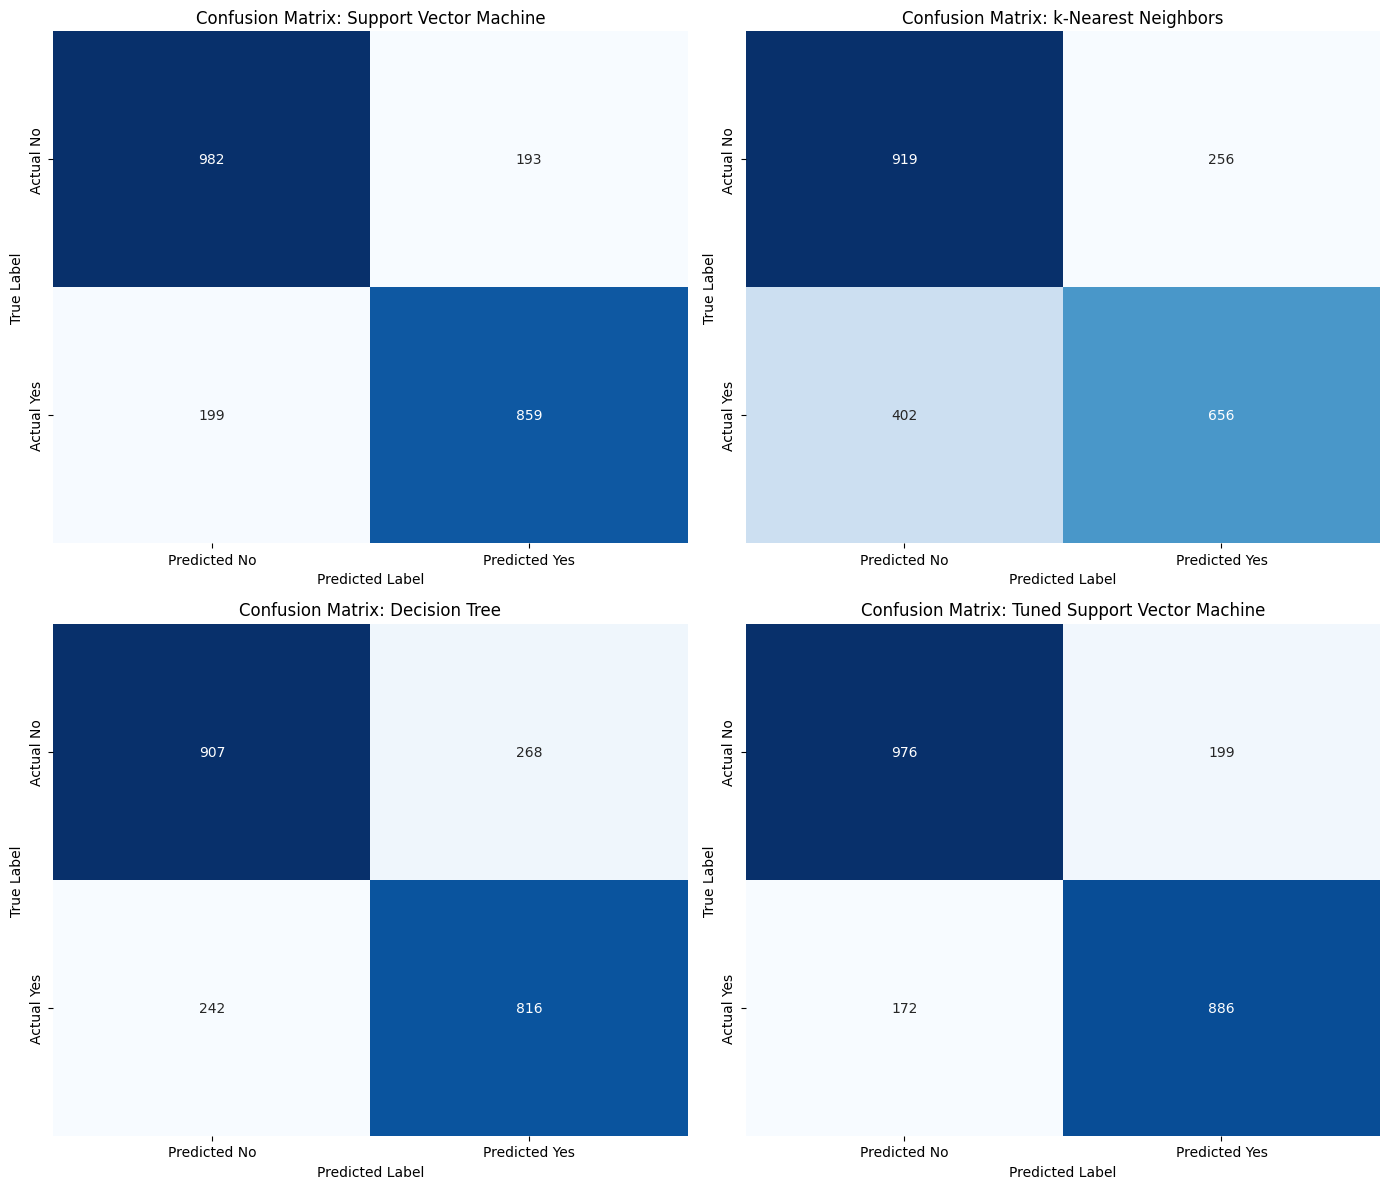

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all results including the tuned SVM
all_results = [
    svm_results,
    knn_results,
    dt_results,
    best_svm_results
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, result in enumerate(all_results):
    model_name = result['model_name']
    conf_matrix = result['confusion_matrix']

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No', 'Actual Yes'], ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {model_name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Key Insights from Confusion Matrices

The confusion matrices provide a granular view into the performance of each model, highlighting their strengths and weaknesses in classifying customer deposits:

*   **Tuned Support Vector Machine (SVM) - Best Performer:** This model demonstrates the most balanced and accurate predictions. It achieves the highest number of True Positives (886) and True Negatives (976), meaning it is highly effective at correctly identifying both customers who will deposit and those who won't. Crucially, it minimizes False Negatives (172), reducing the number of missed opportunities for potential deposits. Its False Positives (199) are also relatively low.

*   **Original Support Vector Machine (SVM):** The untuned SVM also performs well, with good balance in True Positives (859) and True Negatives (982). Its performance is slightly lower than the tuned version, particularly in identifying actual deposits (higher False Negatives at 199), which highlights the positive impact of hyperparameter tuning.

*   **Decision Tree:** The Decision Tree performs moderately. While it identifies a fair number of True Positives (816), it exhibits a higher rate of False Positives (268) compared to both SVM models, meaning it's more prone to incorrectly predicting deposits. Its False Negatives (242) are also higher than both SVM versions, indicating more missed deposit opportunities.

*   **k-Nearest Neighbors (kNN) - Weakest Performer:** The kNN model shows the weakest performance, characterized by a significantly higher number of False Negatives (402) and False Positives (256). This indicates that kNN struggles considerably with both identifying actual deposits (many missed) and making incorrect positive predictions. Its overall lower counts of True Positives (656) and True Negatives (919) reflect its reduced accuracy compared to the other models.

**Overall Conclusion from Confusion Matrices:** The SVM models, especially after tuning, consistently outperform the kNN and Decision Tree models by effectively minimizing both False Positives and False Negatives, leading to more reliable and balanced predictions for customer deposits. The tuned SVM strikes the best balance between precision and recall, making it the most robust choice for this classification task.

### Final Summary Table of All Model Metrics for Report

This table consolidates the key performance metrics (Accuracy, Precision, Recall, F1-Score) for all evaluated models, including the original versions of SVM, kNN, and Decision Tree, as well as the hyperparameter-tuned SVM. This provides a complete overview for reporting purposes.

In [ ]:
import pandas as pd

# Combine all model results into a single list
final_results_data = [
    svm_results,
    knn_results,
    dt_results,
    best_svm_results
]

# Create a DataFrame from the combined results
final_performance_df = pd.DataFrame(final_results_data)

# Drop the 'confusion_matrix' for a cleaner summary table
final_performance_df = final_performance_df.drop(columns=['confusion_matrix'])

# Sort by F1-Score in descending order to easily see the best performing models
final_performance_df = final_performance_df.sort_values(by='f1_score', ascending=False).reset_index(drop=True)

print("\n--- Final Summary of Model Performance ---")
display(final_performance_df.set_index('model_name'))


--- Final Summary of Model Performance ---


,accuracy,precision,recall,f1_score
model_name,,,,
Tuned Support Vector Machine,0.833856,0.816590,0.837429,0.826878
Support Vector Machine,0.824451,0.816540,0.811909,0.814218
Decision Tree,0.771608,0.752768,0.771267,0.761905
k-Nearest Neighbors,0.705329,0.719298,0.620038,0.665990


In [ ]:
# Export the final performance DataFrame to a CSV file
final_performance_df.to_csv('model_performance_summary.csv', index=False)

print("Final model performance summary exported to 'model_performance_summary.csv'")

Final model performance summary exported to 'model_performance_summary.csv'


# 9. Final Conclusion

#Understanding Why the Tuned SVM Achieved the Best Results

The comparative analysis of the three classification models—Support Vector Machine (SVM), k-Nearest Neighbors (kNN), and Decision Tree—shows that the tuned SVM delivered the strongest overall performance on the bank marketing dataset. This can be explained by examining the nature of the dataset as well as the way each algorithm learns patterns from the data.

Dataset Characteristics and Their Impact

One important aspect of the dataset is its high dimensionality after preprocessing. Since categorical variables were transformed using one-hot encoding, the total number of input features increased significantly to 36 features. When the number of dimensions becomes larger, some algorithms—especially those based on distance calculations—can struggle because the difference between data points becomes less distinct.

Another important characteristic is the imbalance in the target variable. The number of customers who did not subscribe to a deposit is greater than the number who did. In such situations, models may become biased toward predicting the majority class more often, which can reduce their ability to correctly identify the minority class.

In addition, all numerical features were scaled using MinMaxScaler, bringing their values into a common range between 0 and 1. This preprocessing step is particularly useful for algorithms such as SVM and kNN, which rely on distance or geometric relationships between data points.

Why the Tuned SVM Performed Best
Support Vector Machine (SVM)

The Support Vector Machine performed best because it is well suited for datasets that contain many features and potentially complex decision boundaries. The main goal of SVM is to find the optimal separating boundary (hyperplane) between classes while maximizing the margin between them. A larger margin generally improves the model’s ability to generalize well on unseen data.

In this project, the RBF kernel was used, which allows the SVM to model non-linear relationships in the data. This is an important advantage because customer behavior and deposit subscription patterns are unlikely to follow a simple straight-line separation. By using a non-linear kernel, the SVM can capture more complex structures in the dataset.

Another reason for its strong performance is that SVM is often effective in high-dimensional feature spaces. Rather than depending on all observations equally, it focuses mainly on the support vectors, which are the most important data points near the decision boundary. This makes it more stable when the number of features is large.

The tuning of hyperparameters such as C and kernel settings also contributed to better performance. Hyperparameter tuning helps the model balance between underfitting and overfitting, allowing it to capture meaningful patterns without becoming too sensitive to noise in the training data. Since the features were scaled beforehand, the SVM could make better use of distances and margins, which further improved its predictive ability.

Why k-Nearest Neighbors (kNN) Performed Worse

The k-Nearest Neighbors (kNN) algorithm showed weaker performance compared to the tuned SVM because of the way it makes predictions. kNN classifies a new sample by looking at the nearest training examples in the feature space and assigning the majority class among those neighbors.

This approach becomes less reliable in high-dimensional datasets. As the number of features increases, distances between data points tend to become more similar, making it difficult to clearly identify which neighbors are actually “close.” This problem is commonly referred to as the curse of dimensionality. Since our dataset contains many one-hot encoded variables, kNN likely struggled to find meaningful neighborhood patterns.

kNN is also sensitive to the distribution of classes. In an imbalanced dataset, the majority class can dominate the neighborhood of many points, which makes the model more likely to predict the majority outcome and miss minority-class cases such as deposit subscriptions. Even though scaling improved the distance calculations, the overall structure of the data still limited the effectiveness of kNN.

Another limitation is that kNN treats all features as part of the distance calculation. If some variables are less informative or noisy, they can still influence the neighbor selection process, which may reduce classification quality.

Why Decision Tree Performed Moderately

The Decision Tree produced moderate results but did not match the tuned SVM. Decision Trees work by repeatedly splitting the dataset into smaller groups based on the feature values that best separate the classes. This makes them easy to interpret and useful for understanding decision rules.

However, a basic or untuned Decision Tree often has a tendency to overfit the training data. It may learn very specific patterns and noise from the training set, which reduces its ability to perform well on new unseen data. If the tree grows too deep without proper pruning or restrictions, this problem becomes more severe.

Another limitation is that Decision Trees create axis-parallel decision boundaries, meaning they split the data feature by feature. While this works well for some problems, it can be less effective when the actual relationship between features and the target variable is complex or non-linear. In comparison, the RBF-based SVM can model smoother and more flexible boundaries, which gives it an advantage in this dataset.

Unlike SVM and kNN, Decision Trees are not heavily affected by feature scaling, so MinMax scaling did not provide a major direct benefit to this model. As a result, although the Decision Tree was able to capture some useful patterns, it was still less powerful than the tuned SVM for this particular classification task.

Overall Conclusion

In summary, the tuned Support Vector Machine achieved the best performance because it was the most capable of handling the structure of the dataset. The combination of high-dimensional input features, scaled numerical variables, and the presence of non-linear relationships favored the SVM approach. Its ability to construct an optimal margin-based boundary, along with hyperparameter tuning, allowed it to classify customers more effectively than the other two models.

The kNN model was limited mainly by the curse of dimensionality and the effect of class imbalance, which reduced the reliability of distance-based neighbor comparisons. The Decision Tree, while easier to interpret, was more prone to overfitting and lacked the flexibility needed to model more complex decision boundaries.

Therefore, based on both the evaluation results and the behavior of the algorithms, the tuned SVM can be considered the most suitable model for predicting whether a customer will subscribe to a term deposit in this bank marketing dataset.